Libraries imported successfully!
Dataset loaded successfully!
Dataset shape: (891, 15)
Number of rows and columns: (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First five rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,Missing Count,Missing Percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


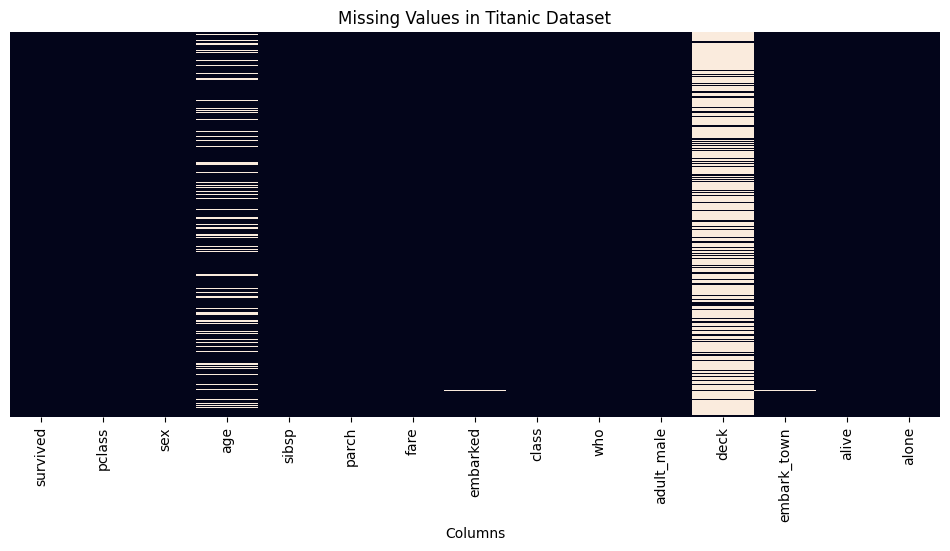

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")
url = (
    "https://raw.githubusercontent.com/"
    "mwaskom/seaborn-data/master/titanic.csv"
)

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all").T)

print("\nFirst five rows:")
display(df.head())
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing = missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing)
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.show()

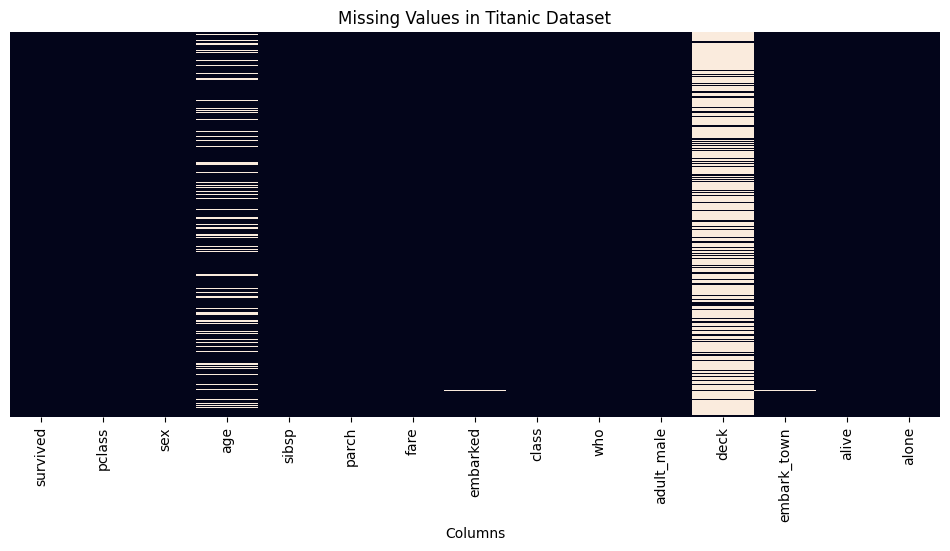

In [ ]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.show()

In [ ]:
clean_df = df.copy()

# Fill missing age values using the median
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

# Fill missing embarkation values using the mode
clean_df["embarked"] = clean_df["embarked"].fillna(
    clean_df["embarked"].mode()[0]
)

# Fill missing fare values using the median
clean_df["fare"] = clean_df["fare"].fillna(
    clean_df["fare"].median()
)

# Drop deck because it has extensive missing data
clean_df = clean_df.drop(columns=["deck"])

print("Missing values after treatment:")
print(clean_df.isnull().sum())

Missing values after treatment:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [ ]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

clean_df = clean_df.drop_duplicates()

print("Shape after removing duplicates:",
      clean_df.shape)

Duplicate rows: 116
Shape after removing duplicates: (775, 14)


In [ ]:
print("Unique values in sex:")
print(clean_df["sex"].unique())

print("\nUnique values in embarked:")
print(clean_df["embarked"].unique())

print("\nUnique values in survived:")
print(clean_df["survived"].unique())

print("\nAge values below zero:",
      (clean_df["age"] < 0).sum())

print("Negative fares:",
      (clean_df["fare"] < 0).sum())

print("Invalid survival values:",
      (~clean_df["survived"].isin([0, 1])).sum())

Unique values in sex:
['male' 'female']

Unique values in embarked:
['S' 'C' 'Q']

Unique values in survived:
[0 1]

Age values below zero: 0
Negative fares: 0
Invalid survival values: 0


In [ ]:
print(clean_df.dtypes)

survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
embark_town     object
alive           object
alone             bool
dtype: object


In [ ]:
numeric_cols = ["age", "fare", "sibsp", "parch"]

outlier_summary = []

for col in numeric_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (clean_df[col] < lower) |
        (clean_df[col] > upper)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Column,Lower Bound,Upper Bound,Outlier Count
0,age,-1.50000,58.50000,27
1,fare,-31.17185,73.41975,102
2,sibsp,-1.50000,2.50000,39
3,parch,-1.50000,2.50000,15


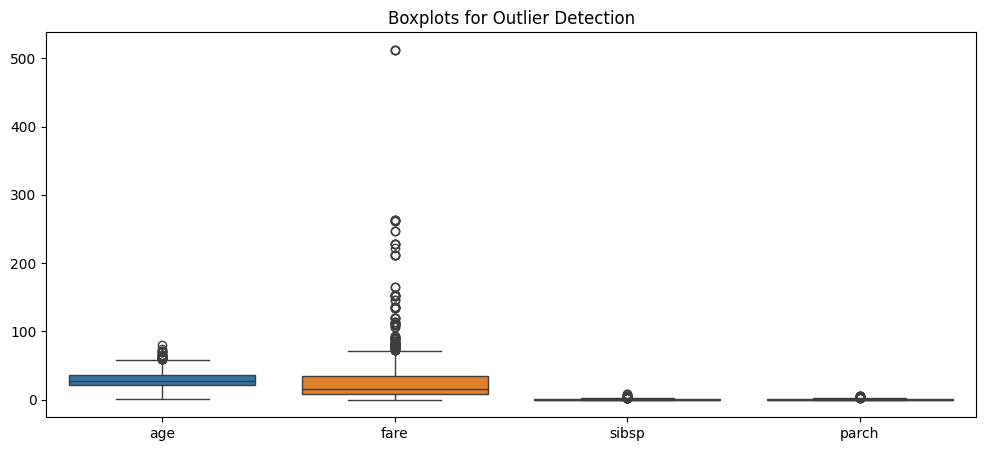

In [ ]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=clean_df[numeric_cols])

plt.title("Boxplots for Outlier Detection")
plt.show()

In [ ]:
model_df = clean_df.copy()

# Convert sex into numerical values
model_df["sex"] = model_df["sex"].map({
    "male": 0,
    "female": 1
})

# One-hot encode embarkation categories
model_df = pd.get_dummies(
    model_df,
    columns=["embarked"],
    dtype=int
)

# Scale selected numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ["age", "fare"]

model_df[scale_cols] = scaler.fit_transform(
    model_df[scale_cols]
)

display(model_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,-0.551060,1,0,-0.527515,Third,man,True,Southampton,no,False,0,0,1
1,1,1,1,0.611945,1,0,0.695086,First,woman,False,Cherbourg,yes,False,1,0,0
2,1,3,1,-0.260308,0,0,-0.514627,Third,woman,False,Southampton,yes,True,0,0,1
3,1,1,1,0.393881,1,0,0.347909,First,woman,False,Southampton,yes,False,0,0,1
4,0,3,0,0.393881,0,0,-0.512240,Third,man,True,Southampton,no,True,0,0,1


In [ ]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", clean_df.shape)

print("\nRemaining missing values:")
print(clean_df.isnull().sum())

print("\nRemaining duplicates:",
      clean_df.duplicated().sum())

print("\nCleaned data preview:")
display(clean_df.head())

clean_df.to_csv(
    "titanic_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully!")

Original dataset shape: (891, 15)
Cleaned dataset shape: (775, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

Remaining duplicates: 0

Cleaned data preview:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Cleaned dataset exported successfully!
